## Exploratory Data Analysis

In [ ]:
import pandas as pd
import numpy as np
import sklearn as sk
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
df_copy = pd.read_csv('./CLEANED_Algerian_forest_fires_dataset_UPDATE.csv')
df = pd.read_csv('./CLEANED_Algerian_forest_fires_dataset_UPDATE.csv')
df_copy.head(10)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0
5,6,6,2012,31,67,14,0.0,82.6,5.8,22.2,3.1,7.0,2.5,fire,0
6,7,6,2012,33,54,13,0.0,88.2,9.9,30.5,6.4,10.9,7.2,fire,0
7,8,6,2012,30,73,15,0.0,86.6,12.1,38.3,5.6,13.5,7.1,fire,0
8,9,6,2012,25,88,13,0.2,52.9,7.9,38.8,0.4,10.5,0.3,not fire,0
9,10,6,2012,28,79,12,0.0,73.2,9.5,46.3,1.3,12.6,0.9,not fire,0


> DROP day, month , year

In [ ]:
df_copy = df_copy.drop(['day', 'month', 'year'], axis=1)

## Encoding of the categories in Classes

In [ ]:
# df_copy['Classes'] = np.where(df_copy['Classes'] == 'not fire', 0, 1)
# df_copy.head(10)

#  We can see here not all categories are fire or not fire . Few have have spaces in it or something else
df_copy['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [ ]:
df_copy['Classes'] = np.where(df_copy['Classes'].str.contains('not fire'), 0, 1)


In [ ]:
df_copy['Classes'].value_counts()

# Successfully converted the Classes column to 0 and 1. Now we can move forward with the EDA of the dataset.

Classes
1    137
0    106
Name: count, dtype: int64

## Let's do visualization

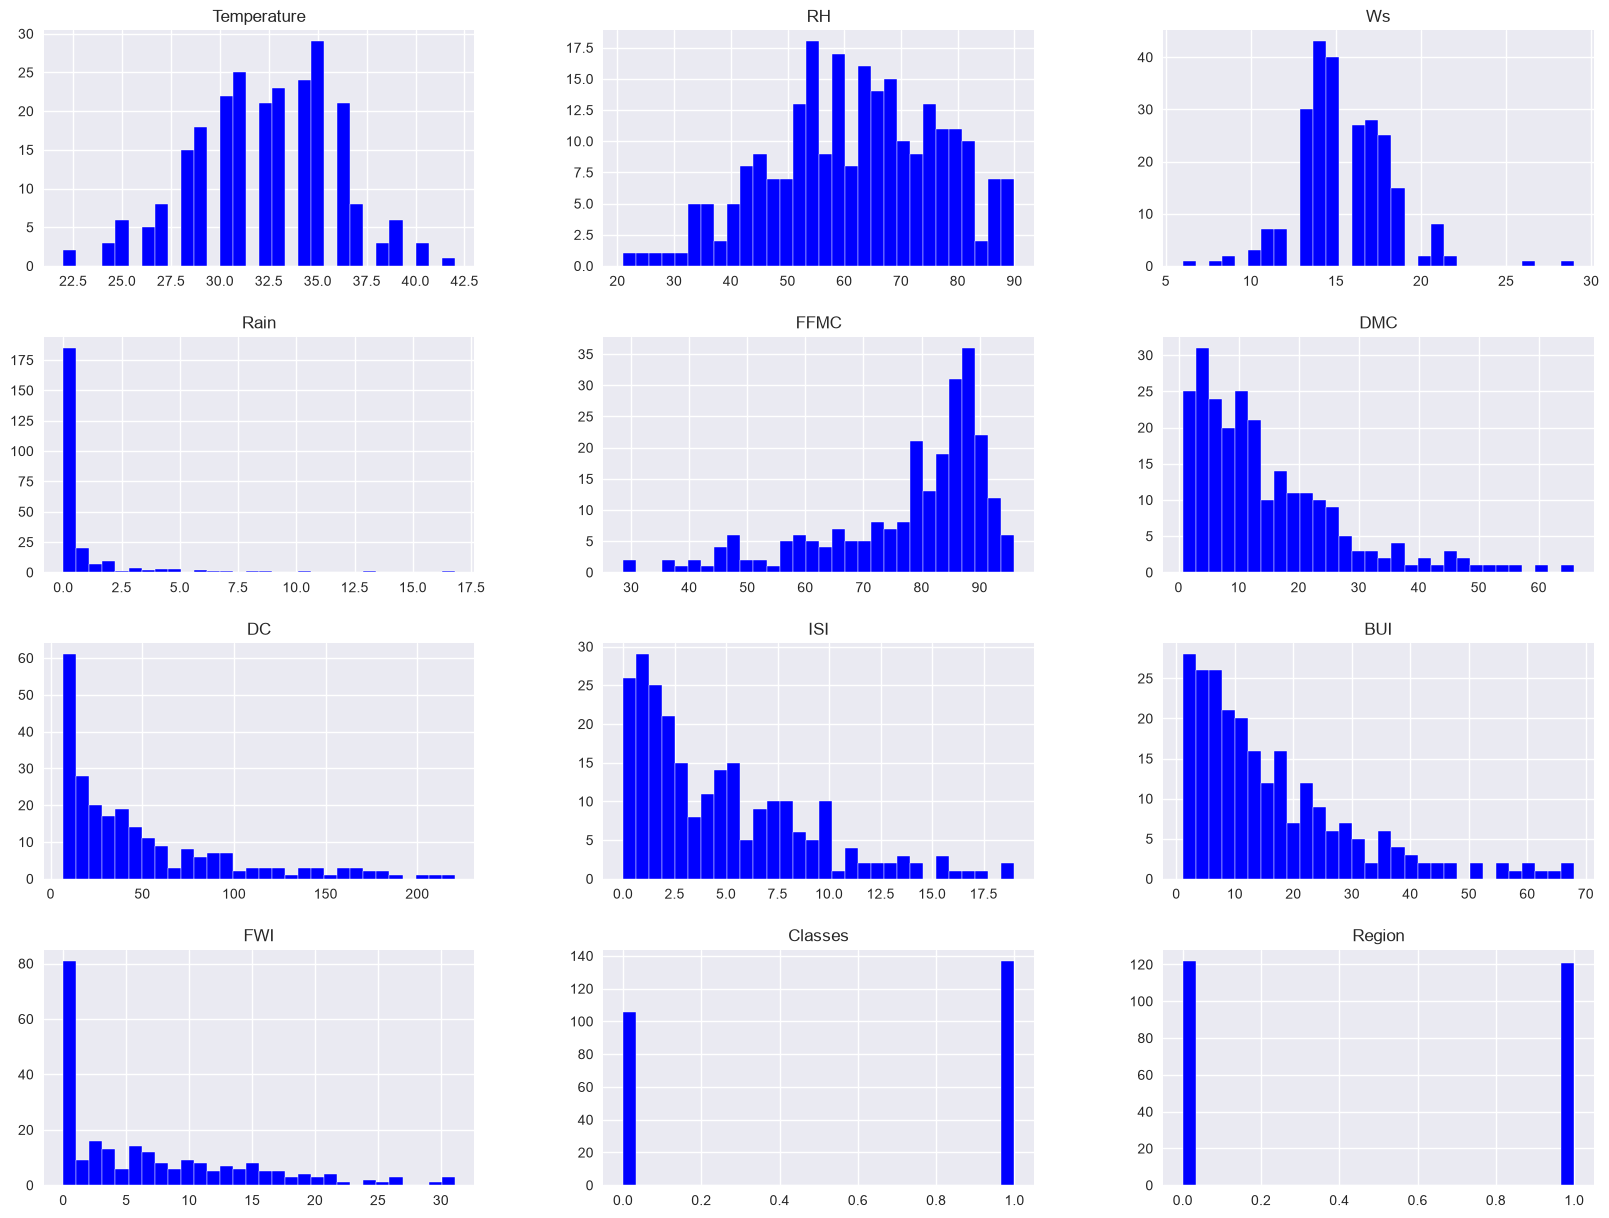

In [ ]:
plt.style.use('seaborn-v0_8')
df_copy.hist(bins=30, figsize=(20, 15), color='blue')
plt.show()

## Percentage for pie chart

Text(0.5, 1.0, 'Percentage of Fire and Not Fire Classes in the Dataset')

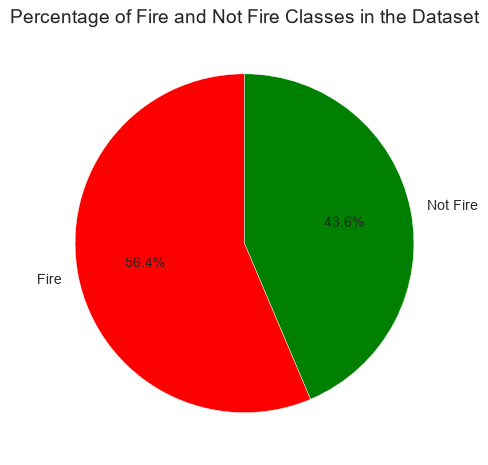

In [ ]:
percentage = df_copy['Classes'].value_counts(normalize=True) * 100

classlables = ["Fire", "Not Fire"]
plt.Figure(figsize=(8, 6))
plt.pie(percentage, labels=classlables, autopct='%1.1f%%', startangle=90, colors=['red', 'green'])
plt.title('Percentage of Fire and Not Fire Classes in the Dataset', fontsize=14)

## Correlation

<Axes: >

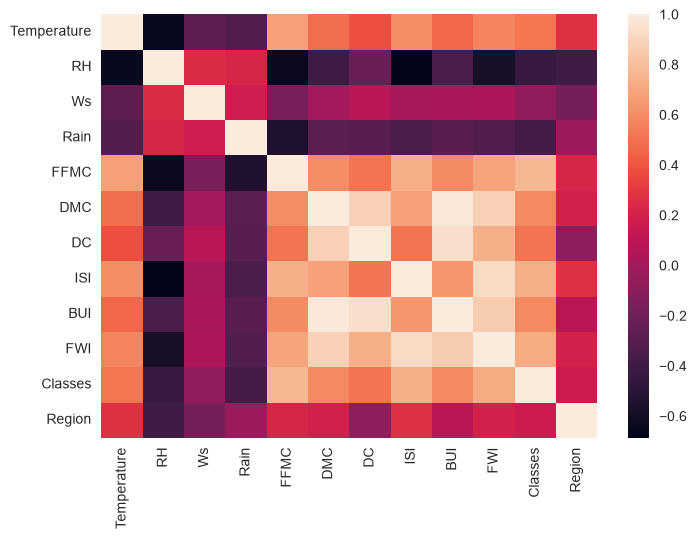

In [ ]:
sns.heatmap(df_copy.corr())

## Box Plots (Identifying the Outliers)

<Axes: ylabel='FWI'>

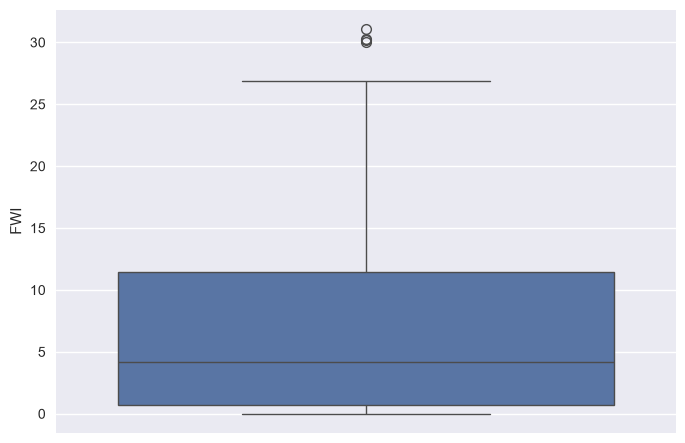

In [ ]:
sns.boxplot(df_copy['FWI'])

In [ ]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


## Monthly Fire Analysis

In [ ]:
df['Classes'] = np.where(df['Classes'].str.contains('not fire'), 'not fire', 'fire')
#  Make the Classes column as fire and not fire for better understanding of the data.

Text(0.5, 1.0, 'Number of Fires in Region 1(sidi - Bel) by Month')

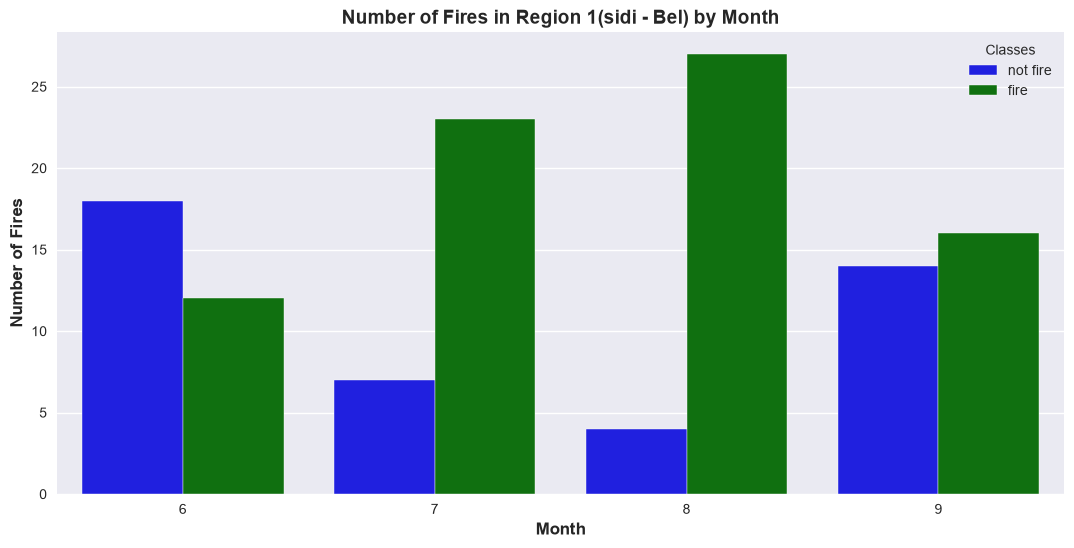

In [ ]:
dftemp = df.loc[df['Region'] == 1]
plt.subplots(figsize=(13, 6))
sns.set_style('whitegrid')
sns.countplot(x='month', hue='Classes', data=dftemp, palette=['blue', 'green'])
plt.ylabel('Number of Fires', weight='bold', fontsize=12)
plt.xlabel('Month', weight='bold', fontsize=12)
plt.title('Number of Fires in Region 1(sidi - Bel) by Month', weight='bold', fontsize=14)

Text(0.5, 1.0, 'Number of Fires in Region 0(Brjaia) by Month')

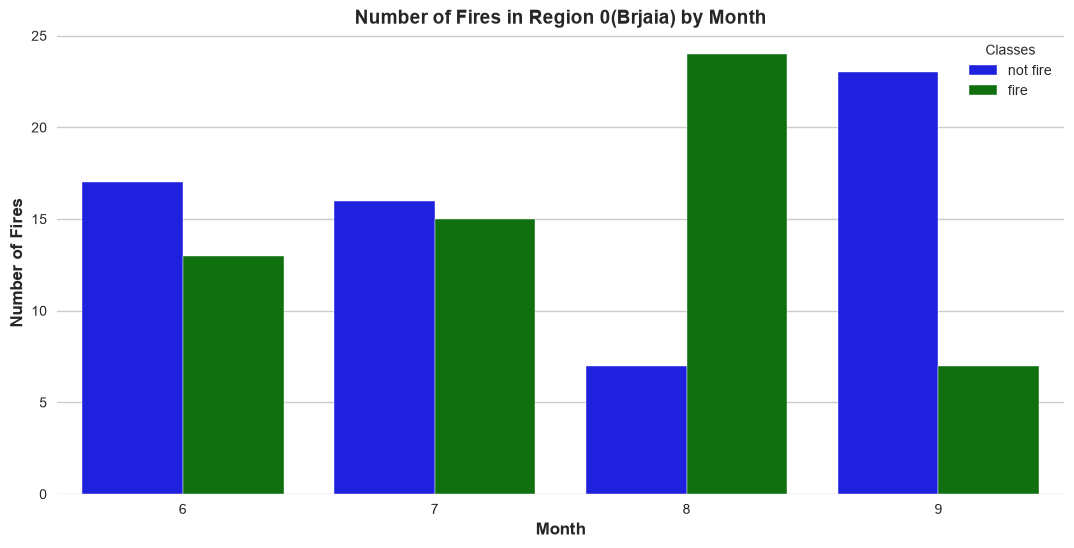

In [ ]:
dftemp = df.loc[df['Region'] == 0]
plt.subplots(figsize=(13, 6))
sns.set_style('whitegrid')
sns.countplot(x='month', hue='Classes', data=dftemp, palette=['blue', 'green'])
plt.ylabel('Number of Fires', weight='bold', fontsize=12)
plt.xlabel('Month', weight='bold', fontsize=12)
plt.title('Number of Fires in Region 0(Brjaia) by Month', weight='bold', fontsize=14)